# Notebook 03 - Modelado y Precómputo de Risk Scores

Los notebooks anteriores produjeron estas capas en S3:

| Notebook | Capa | Contenido |
|----------|------|-----------|
| 01 - ETL | Bronze / Silver | CSVs crudos y datos limpios de la flota |
| 02 - EDA + Features | Silver → Gold | Features engineered para el modelo |

Este notebook genera la capa **Gold/risk_scores** y  **model.pkl**.

## Instalación de dependencias

In [2]:
%pip install -r ../requirements.txt -q

Note: you may need to restart the kernel to use updated packages.


---
## 1. Configuración

In [1]:
import json
import logging
import warnings
from datetime import datetime
from pathlib import Path

import awswrangler as wr
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, classification_report,
                              ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

logging.basicConfig(
    level   = logging.INFO,
    format  = "%(asctime)s | %(levelname)s | %(message)s",
    datefmt = "%Y-%m-%d %H:%M:%S",
    force   = True,
)
log = logging.getLogger("notebook_03")

with open("../config.yaml") as f:
    CFG = yaml.safe_load(f)

BUCKET       = CFG["aws"]["s3_bucket"]
SILVER_PATH  = f"s3://{BUCKET}/{CFG['aws']['s3_paths']['silver']}"
GOLD_PATH    = f"s3://{BUCKET}/{CFG['aws']['s3_paths']['gold']}"
RSK_PATH     = f"s3://{BUCKET}/{CFG['aws']['s3_paths']['risk_scores']}"
MODEL_PATH   = f"s3://{BUCKET}/{CFG['aws']['s3_paths']['models']}"

log.info("Config cargada — bucket: %s | región: %s", BUCKET, CFG["aws"]["region"])
log.info("Gold        : %s", GOLD_PATH)
log.info("Risk scores : %s", RSK_PATH)
log.info("Models      : %s", MODEL_PATH)

2026-05-22 02:17:22 | INFO | Config cargada — bucket: itam-final-azucena | región: us-east-1


2026-05-22 02:17:22 | INFO | Gold        : s3://itam-final-azucena/auto-repair-shop/gold


2026-05-22 02:17:22 | INFO | Risk scores : s3://itam-final-azucena/auto-repair-shop/gold/risk_scores


2026-05-22 02:17:22 | INFO | Models      : s3://itam-final-azucena/auto-repair-shop/models


---
## 2. Carga desde Gold

In [2]:
log.info("Leyendo Gold/features...")
df_gold = wr.s3.read_parquet(path=f"{GOLD_PATH}/features/", dataset=True)
log.info("✓ Gold shape: %d filas x %d columnas", *df_gold.shape)
df_gold.head(3)

2026-05-22 02:17:22 | INFO | Leyendo Gold/features...


2026-05-22 02:17:23 | INFO | Initializing a Ray instance


2026-05-22 02:17:24,592	WARNING services.py:2137 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 1909420032 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=4.62gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.


2026-05-22 02:17:24,737	INFO worker.py:2007 -- Started a local Ray instance.


2026-05-22 02:17:27 | INFO | ✓ Gold shape: 92000 filas x 17 columnas


,Usage_Hours,Tire_Pressure,Fuel_Consumption,Battery_Status,Vibration_Levels,Failure_History,Anomalies_Detected,Delivery_Times,days_since_maintenance,load_ratio,Vehicle_Type,Route_Info,Oil_Quality,Brake_Condition,Weather_Conditions,Road_Conditions,Maintenance_Required
0,530,20.0,5.000000,45.0,2.247033,1,0,30.000000,1139,1.195061,Truck,Rural,80.39380337354066,Good,Clear,Highway,1
1,10679,20.0,5.000000,45.0,0.851417,1,0,30.000000,1037,0.796663,Van,Rural,91.30246087921014,Fair,Clear,Rural,1
2,4181,55.0,13.006892,50.0,4.984557,1,1,48.627823,1162,1.036157,Van,Rural,70.10902101641098,Good,Clear,Highway,1


---
## 3. Preparación del dataset

In [3]:
TARGET        = CFG["modeling"]["target_col"]
NUMERIC_FEATS = CFG["modeling"]["features"]["numeric"]
CAT_FEATS     = CFG["modeling"]["features"]["categorical"]
SEED          = CFG["modeling"]["random_seed"]
TEST_SIZE     = CFG["modeling"]["test_size"]

X = df_gold[NUMERIC_FEATS + CAT_FEATS]
y = df_gold[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

log.info("Train : %d | Test : %d", X_train.shape[0], X_test.shape[0])
log.info("Balance train — 0: %d | 1: %d", (y_train==0).sum(), (y_train==1).sum())

2026-05-22 02:17:27 | INFO | Train : 73600 | Test : 18400


2026-05-22 02:17:27 | INFO | Balance train — 0: 17076 | 1: 56524


---
## 4. Pipeline de preprocesamiento + XGBoost

In [4]:
xgb_params = CFG["modeling"]["xgboost"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUMERIC_FEATS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), CAT_FEATS),
])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   XGBClassifier(
        n_estimators      = xgb_params["n_estimators"],
        max_depth         = xgb_params["max_depth"],
        learning_rate     = xgb_params["learning_rate"],
        subsample         = xgb_params["subsample"],
        colsample_bytree  = xgb_params["colsample_bytree"],
        random_state      = SEED,
        eval_metric       = "logloss",
        use_label_encoder = False,
        tree_method = xgb_params["tree_method"]
    ))
])

log.info("Entrenando XGBoost...")
model.fit(X_train, y_train)
log.info("✓ Entrenamiento completado")

2026-05-22 02:17:27 | INFO | Entrenando XGBoost...


2026-05-22 02:17:29 | INFO | ✓ Entrenamiento completado


---
## 5. Evaluación del modelo

In [5]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]
accuracy    = accuracy_score(y_test, y_pred)

log.info("Accuracy en test: %.4f", accuracy)
print(classification_report(y_test, y_pred,
                             target_names=["No requiere (0)", "Requiere (1)"]))

2026-05-22 02:17:32 | INFO | Accuracy en test: 0.9998


                 precision    recall  f1-score   support

No requiere (0)       1.00      1.00      1.00      4269
   Requiere (1)       1.00      1.00      1.00     14131

       accuracy                           1.00     18400
      macro avg       1.00      1.00      1.00     18400
   weighted avg       1.00      1.00      1.00     18400



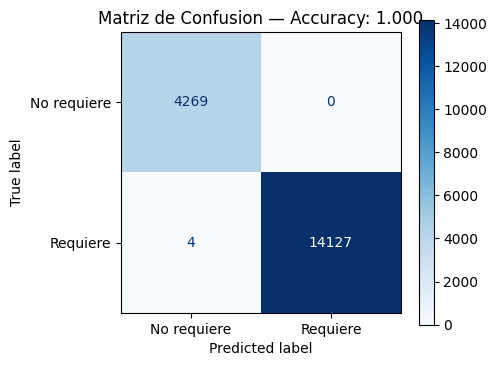

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No requiere", "Requiere"],
    cmap="Blues", ax=ax
)
ax.set_title(f"Matriz de Confusion — Accuracy: {accuracy:.3f}")
plt.tight_layout()
plt.show()

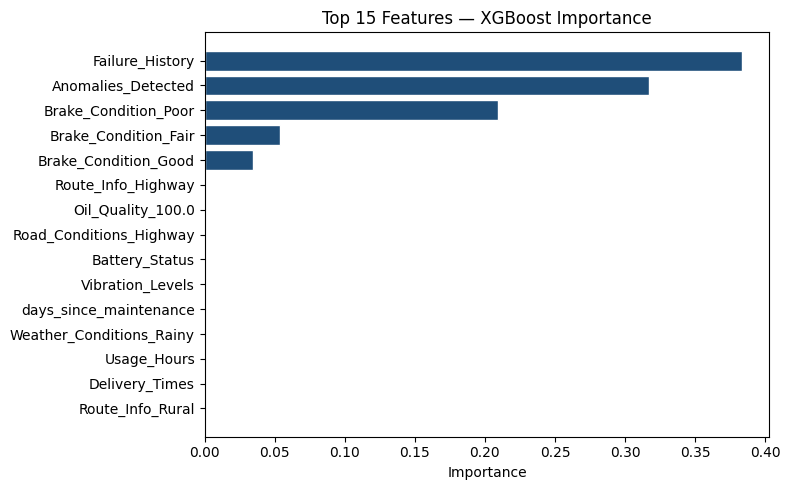

In [7]:
feat_names = (NUMERIC_FEATS +
              list(model.named_steps["preprocessor"]
                   .named_transformers_["cat"]
                   .get_feature_names_out(CAT_FEATS)))
importances = model.named_steps["classifier"].feature_importances_

imp_df = (pd.DataFrame({"feature": feat_names, "importance": importances})
          .sort_values("importance", ascending=True)
          .tail(15))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df["feature"], imp_df["importance"], color="#1F4E79", edgecolor="white")
ax.set_title("Top 15 Features — XGBoost Importance", fontsize=12)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

In [8]:
threshold = CFG["modeling"]["accuracy_threshold"]
if accuracy < threshold:
    log.warning("Accuracy %.4f por debajo del umbral %.2f", accuracy, threshold)
else:
    log.info("✓ Accuracy OK — %.4f >= %.2f", accuracy, threshold)

2026-05-22 02:17:45 | INFO | ✓ Accuracy OK — 0.9998 >= 0.80


---
## 6. Guardar modelo en S3

In [9]:
MODEL_VERSION = datetime.now().strftime("%Y%m%d_%H%M")
MODEL_KEY     = CFG["modeling"]["model_artifact"]
local_path    = Path(f"/tmp/{MODEL_KEY}")

joblib.dump(model, local_path)
wr.s3.upload(local_file=str(local_path), path=f"{MODEL_PATH}/{MODEL_KEY}")

log.info("✓ Modelo guardado en S3: %s/%s", MODEL_PATH, MODEL_KEY)
log.info("  Model version : %s", MODEL_VERSION)
log.info("  Accuracy      : %.4f", accuracy)

2026-05-22 02:17:49 | INFO | ✓ Modelo guardado en S3: s3://itam-final-azucena/auto-repair-shop/models/model_xgb.pkl


2026-05-22 02:17:49 | INFO |   Model version : 20260522_0217


2026-05-22 02:17:49 | INFO |   Accuracy      : 0.9998


---
## 7. Pre-cómputo de risk scores


| Risk Level | Rango |
|---|---|
| Alto  | score >= 70 |
| Medio | 40 <= score < 70 |
| Bajo  | score < 40 |

In [10]:
log.info("Leyendo Gold para pre-cómputo...")
df_gold_all = wr.s3.read_parquet(path=f"{GOLD_PATH}/features/", dataset=True)
log.info("✓ Gold shape: %d filas x %d columnas", *df_gold_all.shape)

# Recalcular days_since_maintenance con la fecha de hoy
df_gold_all["days_since_maintenance"] = (
    pd.Timestamp(datetime.today().date()) -
    pd.to_datetime(df_gold_all["Last_Maintenance_Date"])
).dt.days.clip(lower=0)

X_all = df_gold_all[NUMERIC_FEATS + CAT_FEATS].copy()

prob  = model.predict_proba(X_all)[:, 1]
pred  = model.predict(X_all)

def risk_level(score: float) -> str:
    if score >= 70: return "Alto"
    if score >= 40: return "Medio"
    return "Bajo"

df_risk = pd.DataFrame({
    "vehicle_id":           df_gold_all["Vehicle_ID"].values,
    "risk_score":           (prob * 100).round(2),
    "maintenance_required": pred.astype(bool),
    "risk_level":           [risk_level(s) for s in prob * 100],
    "computed_at":          datetime.utcnow(),
    "model_version":        MODEL_VERSION,
})

log.info("✓ Risk scores calculados: %d vehículos", len(df_risk))
log.info("Distribución risk_level:\n%s", df_risk["risk_level"].value_counts().to_string())


2026-05-22 02:33:21 | INFO | Leyendo Gold para pre-cómputo...


2026-05-22 02:33:22 | INFO | ✓ Gold shape: 92000 filas x 19 columnas


2026-05-22 02:33:24 | INFO | ✓ Risk scores calculados: 92000 vehículos


2026-05-22 02:33:24 | INFO | Distribución risk_level:
risk_level
Alto    70633
Bajo    21367


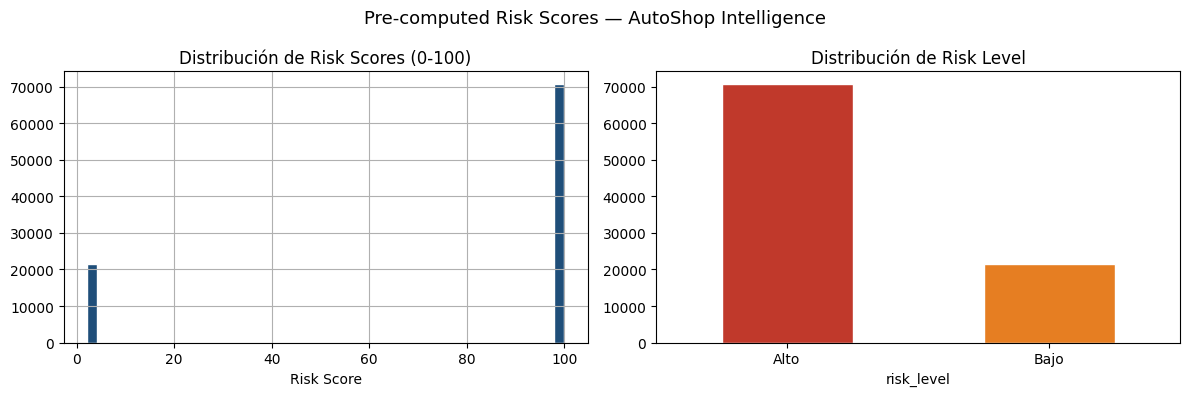

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_risk["risk_score"].hist(ax=axes[0], bins=50, color="#1F4E79", edgecolor="white")
axes[0].set_title("Distribución de Risk Scores (0-100)")
axes[0].set_xlabel("Risk Score")

df_risk["risk_level"].value_counts().plot(
    kind="bar", ax=axes[1],
    color=["#C0392B", "#E67E22", "#27AE60"], edgecolor="white"
)
axes[1].set_title("Distribución de Risk Level")
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("Pre-computed Risk Scores — AutoShop Intelligence", fontsize=13)
plt.tight_layout()
plt.show()

---
## 8. Guardar risk_scores en S3 Gold

In [12]:
log.info("Guardando risk_scores en S3 Gold...")
wr.s3.to_parquet(
    df      = df_risk,
    path    = RSK_PATH,
    dataset = True,
    mode    = "overwrite",
)
log.info("✓ Risk scores guardados en: %s", RSK_PATH)

2026-05-22 02:37:20 | INFO | Guardando risk_scores en S3 Gold...


2026-05-22 02:37:20 | INFO | ✓ Risk scores guardados en: s3://itam-final-azucena/auto-repair-shop/gold/risk_scores


---
## 9. Guardar metadata del modelo en S3

In [14]:
metadata = {
    "model_version":  MODEL_VERSION,
    "trained_at":     datetime.utcnow().isoformat(),
    "accuracy":       round(float(accuracy), 6),
    "n_vehicles":     int(len(df_gold_all)),
    "features_used":  ",".join(NUMERIC_FEATS + CAT_FEATS),
}

metadata_path = f"{MODEL_PATH}/model_metadata.json"
import boto3, json as _json
s3 = boto3.client("s3")
s3.put_object(
    Bucket = BUCKET,
    Key    = f"{CFG['aws']['s3_paths']['models']}/model_metadata.json",
    Body   = _json.dumps(metadata, indent=2),
)
log.info("✓ Metadata guardada en: %s", metadata_path)

2026-05-22 02:58:22 | INFO | ✓ Metadata guardada en: s3://itam-final-azucena/auto-repair-shop/models/model_metadata.json


---
## 10. Verificación final

In [16]:
df_risk_check = wr.s3.read_parquet(path=RSK_PATH, dataset=True)
log.info("Risk scores leidos desde S3: %s", df_risk_check.shape)

assert len(df_risk_check) == len(df_risk), "Discrepancia en risk scores"
assert df_risk_check["risk_score"].between(0, 100).all(), "Scores fuera de rango"

log.info("✓ Verificacion OK — NB03 finalizado")
log.info("  Modelo    : %s", MODEL_VERSION)
log.info("  Accuracy  : %.4f", accuracy)
log.info("  Vehiculos : %d", len(df_risk))

2026-05-22 02:58:48 | INFO | Risk scores leidos desde S3: (92000, 6)


2026-05-22 02:58:48 | INFO | ✓ Verificacion OK — NB03 finalizado


2026-05-22 02:58:48 | INFO |   Modelo    : 20260522_0217


2026-05-22 02:58:48 | INFO |   Accuracy  : 0.9998


2026-05-22 02:58:48 | INFO |   Vehiculos : 92000
